## Project 4 Group-152-01

#### Initial Setup:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

#### Load in data:

In [5]:
#CSV file:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
co_nri = all_tracts[all_tracts["STATE"] == "Colorado"]
wy_nri = all_tracts[all_tracts["STATE"] == "Wyoming"]
co_svi = pd.read_csv("Colorado.csv")
wy_svi = pd.read_csv("Wyoming.csv")

#SHP file:
shp_tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

## Merging data
We will merge the nri and svi tables into one dataframe.

In [8]:
co_nri['STCNTY'] = co_nri['STCOFIPS']
co_data = pd.merge(co_nri, co_svi, on = 'STCNTY', suffixes=('', '_right'))
co_data = pd.DataFrame(co_data)
co_data.columns

C:\Users\willm\AppData\Local\Temp\ipykernel_11404\1429240039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  co_nri['STCNTY'] = co_nri['STCOFIPS']


Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [9]:
wy_nri['STCNTY'] = wy_nri['STCOFIPS']
wy_data = pd.merge(wy_nri, wy_svi, on = 'STCNTY', suffixes=('', '_right'))
wy_data = pd.DataFrame(wy_data)
wy_data.columns

C:\Users\willm\AppData\Local\Temp\ipykernel_11404\1278567897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wy_nri['STCNTY'] = wy_nri['STCOFIPS']


Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

## Risk Definition
We will now compare the NRI's risk definition with the one our team came up with.\
\
NRI defines risk with the following:\
<span style="color:red">Risk</span> = <span style="color:orange">Expected Annual Loss</span> x Community Risk Factor\
&nbsp;&nbsp; - Community Risk Factor = f(<span style="color:green">Social Vulnerability</span>/ <span style="color:purple">Community Resilience)</span>\
&nbsp;&nbsp; - <span style="color:orange">Expected Annual Loss</span> = Exposure x Annualized Frequency x Historical Loss Ratio\
\
Our Team will use the following definition of risk:\
<span style="color:red">Risk</span> = (<span style="color:blue">Probability</span> x <span style="color:orange">Impact</span>) / <span style="color:purple">Preparedness</span>\
&nbsp;&nbsp; - <span style="color:blue">Probability</span> = Frequency\
&nbsp;&nbsp; - <span style="color:orange">Impact</span> = Expected Annual Loss x Exposure\
&nbsp;&nbsp; - <span style="color:purple">Preparedness</span> = Social Vulnerability x Community Resilience

In [35]:
#Adding our risk score
#Multiply by 1/200000 to get score in similar range as NRI score
co_data['Custom_Risk'] = (1/200000)*(co_data['WFIR_AFREQ']*co_data['WFIR_EALT']*co_data['WFIR_EXPT'])/(co_data['SOVI_SCORE']*co_data['RESL_SCORE'])
wy_data['Custom_Risk'] = (1/200000)*(wy_data['WFIR_AFREQ']*wy_data['WFIR_EALT']*wy_data['WFIR_EXPT'])/(wy_data['SOVI_SCORE']*wy_data['RESL_SCORE'])

#### County Risk Comparison

In [33]:
co_county_data = co_data.groupby('COUNTY').agg(mean_nri=('WFIR_RISKV','mean'),
                                               mean_custom=('Custom_Risk','mean'))
wy_county_data = wy_data.groupby('COUNTY').agg(mean_nri=('WFIR_RISKV','mean'),
                                               mean_custom=('Custom_Risk','mean'))

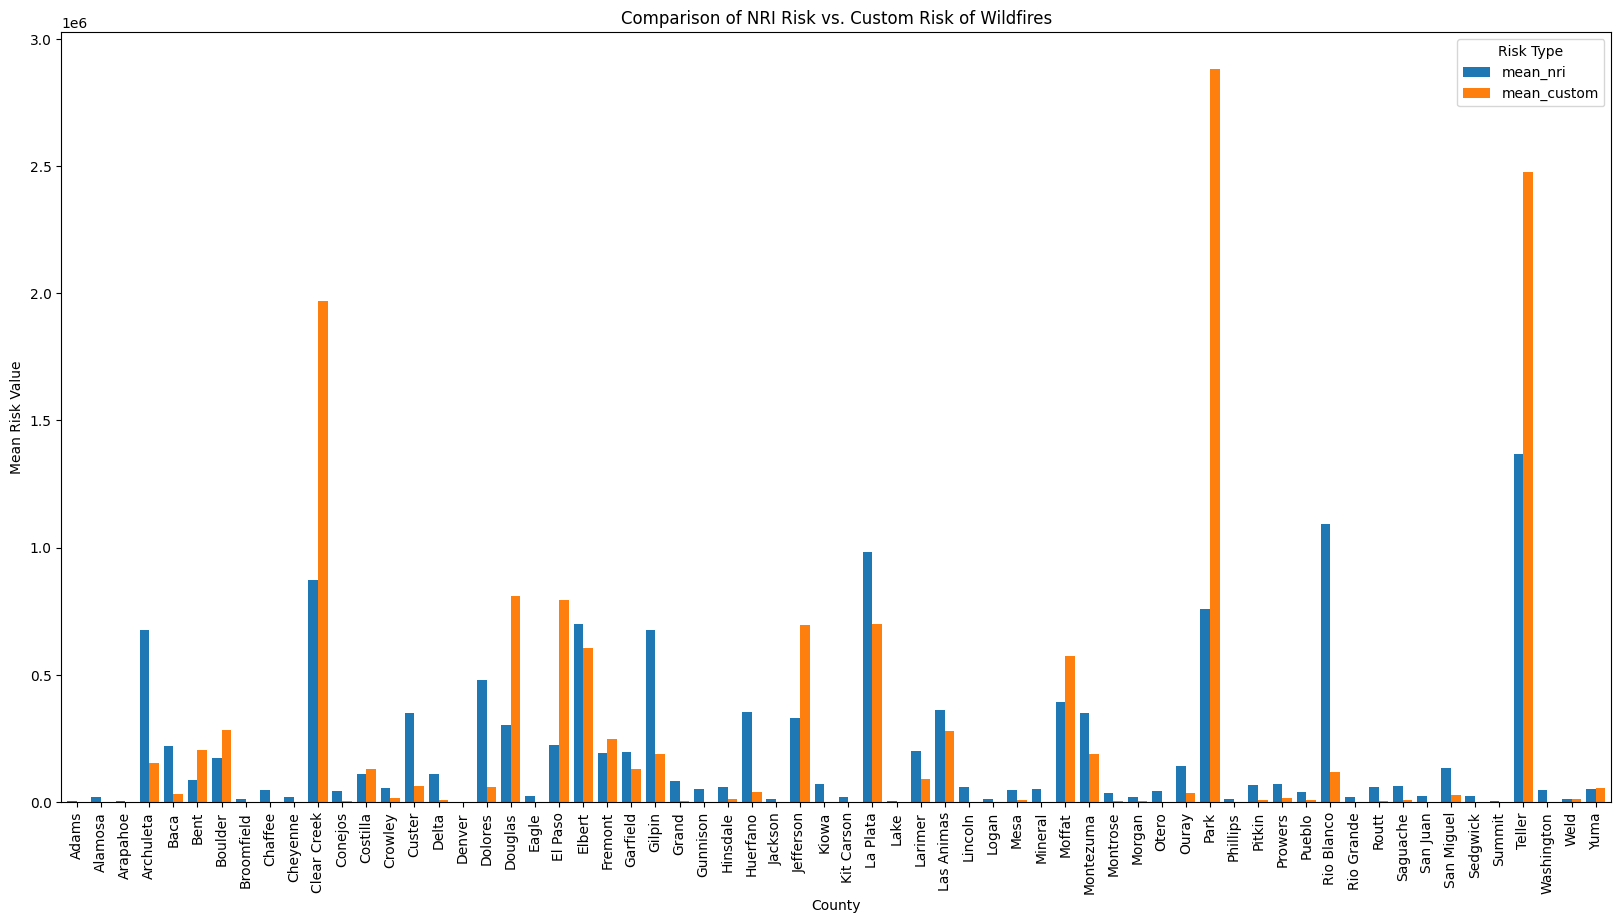

In [34]:
co_county_data.plot(kind='bar', figsize=(20,10), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of NRI Risk vs. Custom Risk of Wildfires in Colorado')
plt.xticks(rotation=90)
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

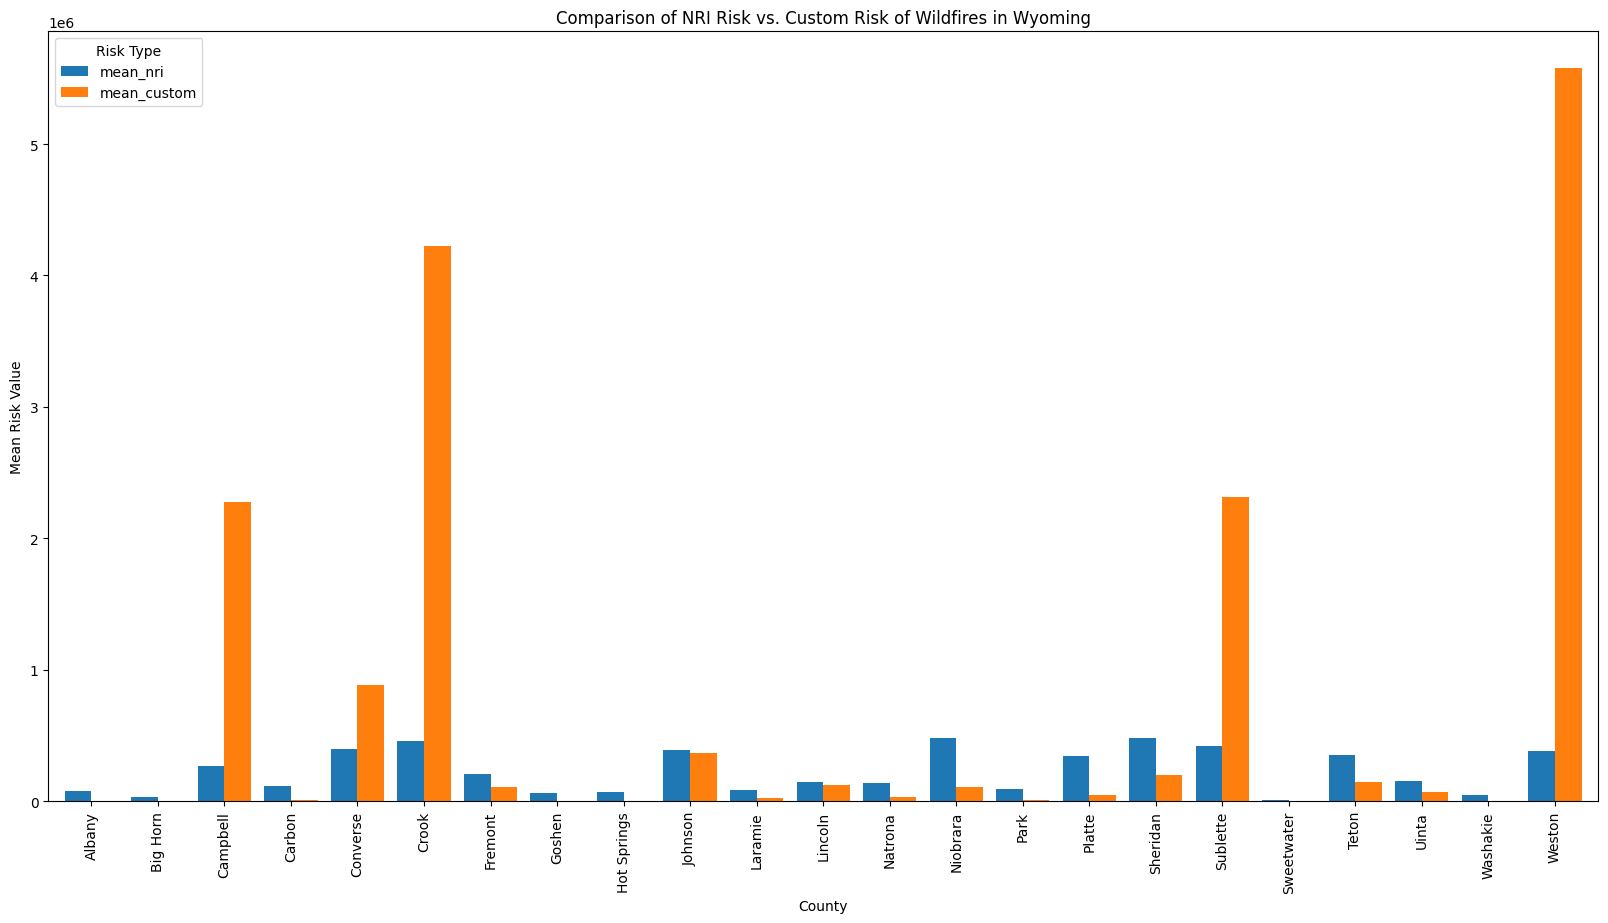

In [36]:
wy_county_data.plot(kind='bar', figsize=(20,10), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of NRI Risk vs. Custom Risk of Wildfires in Wyoming')
plt.xticks(rotation=90)
plt.legend(title="Risk Type")  # Adding a legend to distinguish risk types
plt.show()

### Geospatial Analysis